In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

In [6]:
df = pd.read_csv('happyscore_income.csv')
df.head()

,country,adjusted_satisfaction,avg_satisfaction,std_satisfaction,avg_income,median_income,income_inequality,region,happyScore,GDP,country.1
0,Armenia,37.0,4.9,2.42,2096.76,1731.506667,31.445556,'Central and Eastern Europe',4.350,0.76821,Armenia
1,Angola,26.0,4.3,3.19,1448.88,1044.240000,42.720000,'Sub-Saharan Africa',4.033,0.75778,Angola
2,Argentina,60.0,7.1,1.91,7101.12,5109.400000,45.475556,'Latin America and Caribbean',6.574,1.05351,Argentina
3,Austria,59.0,7.2,2.11,19457.04,16879.620000,30.296250,'Western Europe',7.200,1.33723,Austria
4,Australia,65.0,7.6,1.80,19917.00,15846.060000,35.285000,'Australia and New Zealand',7.284,1.33358,Australia


In [7]:
df.columns

Index(['country', 'adjusted_satisfaction', 'avg_satisfaction',
       'std_satisfaction', 'avg_income', 'median_income', 'income_inequality',
       'region', 'happyScore', 'GDP', 'country.1'],
      dtype='object')

In [49]:
df.sort_values('GDP', inplace=True)
df.head(5)

,country,adjusted_satisfaction,avg_satisfaction,std_satisfaction,avg_income,median_income,income_inequality,region,happyScore,GDP,country.1
10,Burundi,25.0,2.9,1.96,572.88,436.92,33.360000,'Sub-Saharan Africa',2.905,0.01530,Burundi
73,Niger,34.0,3.8,1.75,718.40,535.56,37.726667,'Sub-Saharan Africa',3.845,0.06940,Niger
58,Liberia,37.0,4.4,2.02,653.04,528.72,36.480000,'Sub-Saharan Africa',4.571,0.07120,Liberia
72,Mozambique,34.0,3.8,1.76,714.72,488.52,45.580000,'Sub-Saharan Africa',4.971,0.08308,Mozambique
32,Ethiopia,33.0,4.2,2.25,1050.72,857.16,33.170000,'Sub-Saharan Africa',4.512,0.19073,Ethiopia


In [74]:
df[(df.GDP < 0.2) & (df.happyScore > 4.9)]

,country,adjusted_satisfaction,avg_satisfaction,std_satisfaction,avg_income,median_income,income_inequality,region,happyScore,GDP,country.1
72,Mozambique,34.0,3.8,1.76,714.72,488.52,45.58,'Sub-Saharan Africa',4.971,0.08308,Mozambique


In [75]:
df[(df.GDP > 1.0) & (df.happyScore < 4.0)]

,country,adjusted_satisfaction,avg_satisfaction,std_satisfaction,avg_income,median_income,income_inequality,region,happyScore,GDP,country.1
35,Gabon,34.0,4.2,2.21,2520.96,1791.48,42.18,'Sub-Saharan Africa',3.896,1.06024,Gabon


In [80]:
row1 = df.iloc[3]
row1

country                            Mozambique
adjusted_satisfaction                      34
avg_satisfaction                          3.8
std_satisfaction                         1.76
avg_income                             714.72
median_income                          488.52
income_inequality                       45.58
region                   'Sub-Saharan Africa'
happyScore                              4.971
GDP                                   0.08308
country.1                          Mozambique
Name: 72, dtype: object

In [85]:
row2 = df[df.country == 'Gabon']
row2

,country,adjusted_satisfaction,avg_satisfaction,std_satisfaction,avg_income,median_income,income_inequality,region,happyScore,GDP,country.1
35,Gabon,34.0,4.2,2.21,2520.96,1791.48,42.18,'Sub-Saharan Africa',3.896,1.06024,Gabon


In [28]:
from sklearn.cluster import KMeans
X = np.column_stack((df.GDP, df.happyScore))
km_res = KMeans(n_clusters=3).fit(X)

In [33]:
cls = km_res.cluster_centers_
cls

array([[0.93366366, 5.4922439 ],
       [1.23009172, 7.01189655],
       [0.47558634, 4.22695122]])

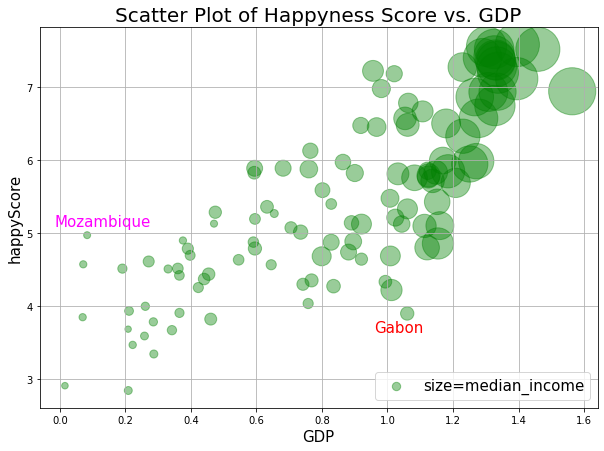

In [87]:
plt.figure(figsize=(10,7))
plt.scatter(df.GDP, df.happyScore, s=df.median_income / 10, color='green', alpha=0.4, label='size=median_income')
#plt.scatter(cls[:,0], cls[:,1], s=1000, color='red', label='points of interest') #KMeans cluster centroids
plt.text(row1['GDP']-0.1, row1['happyScore']+0.125, row1['country'], size=15, color='magenta')
plt.text(row2.GDP.values[0]-0.1, row2.happyScore.values[0]-0.25, row2.country.values[0], size=15, color='red')
plt.xlabel('GDP', size=15)
plt.ylabel('happyScore', size=15)
plt.legend(loc="lower right", markerscale=.25, scatterpoints=1, fontsize=15)
plt.title('Scatter Plot of Happyness Score vs. GDP', size=20)
plt.grid()
plt.show()

In [22]:
df[['happyScore', 'GDP']].corr()

,happyScore,GDP
happyScore,1.000000,0.790061
GDP,0.790061,1.000000
